In [1]:
from utils import *

import torch as th
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

from sklearn.model_selection import KFold

import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms


import tqdm



In [2]:
# Paths
img_dir = 'data/Databases/Quality/'
json_path = 'data/Databases/Quality/labels.json'

class ImageDataset(Dataset):
    def __init__(self, img_dir, json_path, transform=None, augment=True):
        self.img_dir = img_dir
        self.transform = transform
        self.augment = augment
        self.img_names = os.listdir(img_dir)
        self.img_names = [name for name in self.img_names if name != "labels.json"]
        self.num_images = len(self.img_names)

        with open(json_path, 'r') as f:
            self.labels_json = json.load(f)

        original_labels = list(self.labels_json["CleanCat"].values())
        unique_labels = sorted(set(original_labels))
        label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.labels = [label_to_idx[label] for label in original_labels]

        self.num_classes = len(unique_labels)

        # Debug prints to verify label mapping
        print(f"Unique labels: {unique_labels}")
        print(f"Label to index mapping: {label_to_idx}")
        print(f"Mapped labels: {self.labels[:10]}")
        print(f"Number of classes: {self.num_classes}")

        
        self.labels = list(self.labels_json["CleanCat"].values())

    def __len__(self):
        return self.num_images * 4 if self.augment else self.num_images
    
    def __getitem__(self, idx):
        # Get the actual image index (mod 4 to handle augmentations)
        img_idx = idx // 4
        augment_idx = idx % 4

        img_name = os.path.join(self.img_dir, self.img_names[img_idx])
        image = Image.open(img_name)
        
        # Apply rotations based on augment_idx
        if augment_idx == 1:
            image = image.rotate(90)
        elif augment_idx == 2:
            image = image.rotate(180)
        elif augment_idx == 3:
            image = image.rotate(270)

        if self.transform:
            image = self.transform(image)

        label = self.labels[img_idx]
        return image, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ImageDataset(img_dir, json_path, transform, augment=True)



# (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
dataset_tr, dataset_te = random_split(dataset, [train_size, test_size])


# DataLoader (regular)
dataloader_tr = DataLoader(dataset=dataset_tr, shuffle=True, batch_size=8)
dataloader_te = DataLoader(dataset=dataset_te, shuffle=True, batch_size=8)


Unique labels: [0, 1, 2, 3]
Label to index mapping: {0: 0, 1: 1, 2: 2, 3: 3}
Mapped labels: [2, 2, 1, 0, 3, 3, 2, 0, 2, 3]
Number of classes: 4


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

class RNet(nn.Module):
    def __init__(self, num_classes=4):
        super(RNet, self).__init__()
        
        self.resnet = models.resnet18(pretrained=True)
        
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, num_classes)
        

    def forward(self, x):
        return self.resnet(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
model = RNet(num_classes=4).to(device)
print(device)

c:\Users\Danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


cuda


In [4]:
def train(model, loader):
    """
    """
    # params
    epochs = 10
    lr = 0.001
    # Loss function
    #loss_func = nn.BCEWithLogitsLoss()
    loss_func = nn.CrossEntropyLoss()

    # Optimizer and model inits
    optimizer = th.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in tqdm.tqdm(range(epochs)):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            loss = loss_func(outputs, labels)

            # Backward pass and gradient update
            loss.backward()
            optimizer.step()
            
            torch.cuda.empty_cache()

            
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
    
    #th.save(model.state_dict(), "resnet18_quality_kfold.pt")
    
    
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(train_loader)


In [5]:
#train(model, dataloader_tr)

# KFold Cross-Validation

In [6]:
# Validation function
def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return running_loss / len(val_loader), accuracy

In [10]:
import torch.optim as optim

# KFold split 
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True)

# params
epochs = 10
lr = 0.0001
# Loss function
loss_func = nn.CrossEntropyLoss()


# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset_tr)):
    print(f'Fold {fold+1}/{k_folds}')
    
    # Create subsets for this fold
    train_subset = Subset(dataset_tr, train_idx)
    val_subset = Subset(dataset_tr, val_idx)
    
    # Create DataLoader for train and validation
    train_loader = DataLoader(train_subset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=4, shuffle=False)
    
    # Initialize the model, loss function, and optimizer for each fold
    model = RNet(num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()  # Replace based on your task
    optimizer = th.optim.Adam(model.parameters(), lr=lr)
    
    best_val_accuracy = 0.0
    
    # Train for a number of epochs 
    for epoch in range(epochs):
        train_loss = train_model(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate_model(model, val_loader, criterion, device)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')
        
        # Save the model if validation accuracy improves
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            # Save the model's state_dict
            model_file = f'RNet_5fold_{fold+1}.pth'
            torch.save(model.state_dict(), os.path.join("trained_models/quality/", model_file))
            print(f'Model saved for fold {fold+1} at epoch {epoch+1} with val accuracy {val_accuracy:.4f}')
    
        
    print(f'Fold {fold+1} finished.\n')

print('Cross-validation complete.')


Fold 1/5
Epoch 1, Train Loss: 0.8450, Val Loss: 0.5836, Val Accuracy: 0.7812
Model saved for fold 1 at epoch 1 with val accuracy 0.7812
Epoch 2, Train Loss: 0.5706, Val Loss: 0.4979, Val Accuracy: 0.8000
Model saved for fold 1 at epoch 2 with val accuracy 0.8000
Epoch 3, Train Loss: 0.4385, Val Loss: 0.6758, Val Accuracy: 0.7719
Epoch 4, Train Loss: 0.2958, Val Loss: 0.7660, Val Accuracy: 0.7438
Epoch 5, Train Loss: 0.2656, Val Loss: 0.5348, Val Accuracy: 0.7969
Epoch 6, Train Loss: 0.2285, Val Loss: 0.6017, Val Accuracy: 0.7656
Epoch 7, Train Loss: 0.1549, Val Loss: 0.6394, Val Accuracy: 0.7656
Epoch 8, Train Loss: 0.1281, Val Loss: 0.5803, Val Accuracy: 0.8125
Model saved for fold 1 at epoch 8 with val accuracy 0.8125
Epoch 9, Train Loss: 0.1421, Val Loss: 0.5928, Val Accuracy: 0.7719
Epoch 10, Train Loss: 0.1726, Val Loss: 0.5340, Val Accuracy: 0.8187
Model saved for fold 1 at epoch 10 with val accuracy 0.8187
Fold 1 finished.

Fold 2/5
Epoch 1, Train Loss: 0.8607, Val Loss: 0.6397,

c:\Users\Danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Danie\AppData\Local\Temp\ipykernel_14968\3338809140.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickl

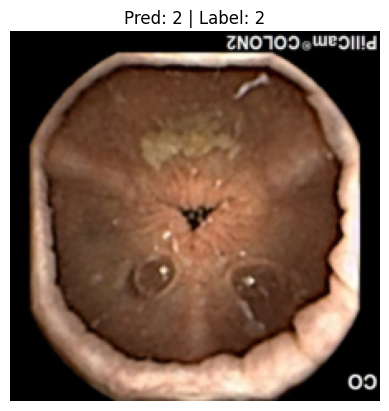

Test Accuracy: 0.8200


: 

In [19]:
import torch as th
import matplotlib.pyplot as plt

# Load the model
model = RNet(num_classes=4).to(device)
model.load_state_dict(th.load("trained_models/quality/RNet_5fold_4.pth"))  # RNet_5fold_4.pth -> acc=82%

# Set the model to evaluation mode
model.eval()

# Test loop
total_images = 0
nr_acc = 0

with th.no_grad():
    for images, labels in dataloader_te:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Predicted classes
        predicted = th.argmax(outputs, dim=1)
        
        # Accuracy calculation
        nr_acc += (predicted == labels).sum().item()
        total_images += labels.size(0)
        
        # Optional: Display the first 10 images with predictions
        if total_images <= 10:
            plt.imshow(images[0].cpu().permute(1, 2, 0).numpy())
            plt.title(f"Pred: {predicted[0].item()} | Label: {labels[0].item()}")
            plt.axis('off')
            plt.show()
    
print(f"Test Accuracy: {nr_acc / total_images:.4f}")
